### Ollama基本使用
> pip install langchain-ollama

In [21]:
import os

from langchain_ollama import ChatOllama
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain.schema import SystemMessage, HumanMessage, AIMessage
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser

In [2]:
from IPython.display import Markdown


def display_markdown(content):
    md = Markdown(content)
    display(md)

#### 1. 基本示例

In [3]:
# 1. 初始化ChatOllama模型，指定模型的名字，这里是deepseek-r1:1.5b
model_name = 'deepseek-r1:1.5b'
ollama_base_url = os.environ.get("OLLAMA_API_BASE")
                                     
chat = ChatOllama(model=model_name, base_url=ollama_base_url)

In [4]:
result = chat.invoke("1 + 1 = ?")
result

AIMessage(content='<think>\nTo solve the equation \\(1 + 1\\), I start by recognizing that addition is a basic arithmetic operation.\n\nNext, I identify the numbers involved in the equation: one and one.\n\nI then perform the addition by combining these two quantities.\n\nFinally, I determine that the result of adding one and one together is two.\n</think>\n\nTo solve \\(1 + 1\\), follow these simple steps:\n\n1. **Identify the numbers to add:**  \n   We have two instances of the number **1**.\n\n2. **Perform the addition:**  \n   \\[\n   1 + 1 = 2\n   \\]\n\n3. **State the final answer:**  \n   The sum of one and one is \\(\\boxed{2}\\).', additional_kwargs={}, response_metadata={'model': 'deepseek-r1:1.5b', 'created_at': '2025-03-03T08:32:45.627401Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1440056625, 'load_duration': 32902792, 'prompt_eval_count': 9, 'prompt_eval_duration': 88000000, 'eval_count': 155, 'eval_duration': 1317000000, 'message': Message(role='assistant',

In [5]:
# OutputParsers: StrOutputParser获取输出
str_parser = StrOutputParser()
str_parser.invoke(result)

'<think>\nTo solve the equation \\(1 + 1\\), I start by recognizing that addition is a basic arithmetic operation.\n\nNext, I identify the numbers involved in the equation: one and one.\n\nI then perform the addition by combining these two quantities.\n\nFinally, I determine that the result of adding one and one together is two.\n</think>\n\nTo solve \\(1 + 1\\), follow these simple steps:\n\n1. **Identify the numbers to add:**  \n   We have two instances of the number **1**.\n\n2. **Perform the addition:**  \n   \\[\n   1 + 1 = 2\n   \\]\n\n3. **State the final answer:**  \n   The sum of one and one is \\(\\boxed{2}\\).'

In [35]:
str_parser.invoke(chat.invoke("请翻译一下内容：This is her book."))

'<think>\n\n</think>\n\n这是她的书。'

#### 链调用

In [27]:
model01 = init_chat_model("qwen2.5:1.5b", model_provider="ollama", base_url=ollama_base_url)
chain01 = model | str_parser

In [28]:
chain01.invoke("请计算100+123的值，直接给出结果")

' 100 + 123 = 223 '

In [34]:
# 结合提示词模板
prompt_template = ChatPromptTemplate.from_messages(
    [
        ("system", "请将以下内容翻译为{language}"),
        ("user", "{text}")
    ]
)
prompt_template.invoke({"language": "中文", "text": "This is you book."})

ChatPromptValue(messages=[SystemMessage(content='请将以下内容翻译为中文', additional_kwargs={}, response_metadata={}), HumanMessage(content='This is you book.', additional_kwargs={}, response_metadata={})])

In [30]:
# 链式调用
chain02 = prompt_template | model01 | str_parser

In [33]:
chain02.invoke({"language": "中文", "text": "This is my book."})

'这是我的一本书。'

#### 2. 定义消息

In [9]:
# 定义系统消息
system_message = SystemMessage(content="你是一个厨艺丰富的智能助手，熟系各种烹饪相关的问题。")

# 定义用户消息
human_message = HumanMessage(content="可乐鸡翅怎么制作？")

In [10]:
# 调用模型生成回复
response = chat.invoke([system_message, human_message])
type(response)

langchain_core.messages.ai.AIMessage

#### 3. 记忆

In [12]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import START, MessagesState, StateGraph

In [13]:
# 定义一个新的graph
workflow = StateGraph(state_schema=MessagesState)

# 定义模型
model_name = "llava:7b"
model = ChatOllama(model=model_name, base_url=ollama_base_url)

# 定义一个函数call model
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": response}

workflow.add_edge(START, "model")
workflow.add_node("model", call_model)

# Add Memory
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

In [14]:
config = {"configurable": {"thread_id": "123"}}

query = "明天是我姐姐的生日我想送她一件礼物，送什么好？"
input_messages = [HumanMessage(query)]
output = app.invoke({"messages": input_messages}, config)
type(output)

langgraph.pregel.io.AddableValuesDict

In [15]:
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

 你选择送一件礼物取决于你和你姐姐的关系和她的喜好。以下几种礼物都是不错的选择：

1. 祝贺卡片：简单又实用，这个礼物可以让你姐姐感到受到了你的关心和爱。
2. 书籍或文章：如果你知道她喜欢什么话题或作者，可以给她一本相关的书籍或写一篇与她共同兴趣的文章。
3. 美妆产品：如果你姐姐是美容爱好，您可以送一些美妆产品，让她享受到新鲜美容体验。
4. 食品礼包：如果你知道她喜欢吃什么，可以送一些她喜欢的食物，比如糖果、巧克力或火锅等。
5. 家居装饰：如果您了解她的住房情况，您可以送一些装饰品，让她的生活更加舒适和美观。
6. 电子产品：如果您知道她喜欢什么类型的电子产品，可以送一些符合她需求的产品，比如手机、头部音响等。
7. 花卉礼包：如果您了解她喜欢花卉或装饰，您可以送一些花卉或装饰品，让她感受到生活的美好。

最终选择的礼物应该是您和你姐姐之间更加亲近的东西，尽量与她共同兴趣相关，让这个礼物成为了你们之间更紧密的联系。


In [16]:
output = app.invoke({"messages": [HumanMessage("明天是谁的生日?请直接给出答案")]}, config)

In [17]:
output["messages"][-1].pretty_print()


================================== Ai Message ==================================

 明天是您姐姐的生日。


In [18]:
output = app.invoke({"messages": [HumanMessage("明天生日的人，是我的谁？")]}, config)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

 明天生日的人是你的姐姐。


In [19]:
type(app)

langgraph.graph.state.CompiledStateGraph

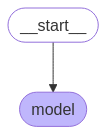

In [20]:
app